In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

sns.set_context("paper")
from tqdm.auto import tqdm

from dti import data
from dti.utils import get_scaffold
from dti.constants import ACT, ASSAY, SMILES, TID

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [3]:
SCAFFOLD = "_scaffold"
BUTINA = "_butina"
UMAP = "_umap"
RANDOM = "_random"

names = {
    TID: "target",
    SCAFFOLD: "scaffold",
    ASSAY: "assay",
    BUTINA: "Butina",
    RANDOM: "random",
}

In [11]:
rng = np.random.default_rng(seed=42)


def get_group_split(df, group_col, test_frac=0.2):
    unique_vals = df[group_col].dropna().unique()
    test_vals = set(
        rng.choice(unique_vals, size=int(len(unique_vals) * test_frac), replace=False)
    )
    test_mask = df[group_col].isin(test_vals)
    return df[~test_mask], df[test_mask], test_vals


def get_random_split(df, test_frac=0.2):
    return train_test_split(df, test_size=test_frac, random_state=42)


def predict_group_mean(train, test, group_col, value_col=ACT):
    group_means = train.groupby(group_col)[value_col].mean()
    overall_mean = train[value_col].mean()
    preds = test[group_col].map(group_means).fillna(overall_mean)
    overlap = test[group_col].isin(group_means.index).mean() * 100
    return preds.values, overlap


def evaluate_predictions(y_true, y_pred):
    mask = ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    pearson = pearsonr(y_true, y_pred)[0]
    kendall = kendalltau(y_true, y_pred).correlation
    r2 = r2_score(y_true, y_pred)
    spearman = spearmanr(y_true, y_pred)[0]
    return round(pearson, 4), round(kendall, 4), round(r2, 4), round(spearman, 4)


def fisher_z(r):
    return np.arctanh(np.clip(r, -0.999999, 0.999999))  # Avoid inf at ±1


def fisher_z_inverse(z):
    return np.tanh(z)


def run_all_combinations(df, dataset_name):
    predictive_criteria = [TID, SCAFFOLD, ASSAY]
    split_criteria = [TID, SCAFFOLD, BUTINA, RANDOM]
    results = []

    for pred_col in tqdm(predictive_criteria):
        for split_col in split_criteria:
            if split_col == pred_col:
                continue

            z_scores = []
            weights = []
            kendall_values = []
            spearman_values = []
            r2_values = []
            overlap_values = []

            for _ in range(5):
                if split_col == RANDOM:
                    train, test = get_random_split(df)
                else:
                    train, test, _ = get_group_split(df, split_col)

                y_pred, overlap = predict_group_mean(train, test, pred_col, ACT)
                p, k, r2, s = evaluate_predictions(test[ACT].values, y_pred)

                z_scores.append(fisher_z(p))
                weights.append(len(test))
                kendall_values.append(k)
                spearman_values.append(s)
                r2_values.append(r2)
                overlap_values.append(overlap)

            z_scores = np.array(z_scores)
            weights = np.array(weights)
            z_mean_weighted = np.average(z_scores, weights=weights)
            z_std_weighted = np.sqrt(
                np.average((z_scores - z_mean_weighted) ** 2, weights=weights)
            )

            results.append(
                {
                    "predictive": pred_col,
                    "split": split_col,
                    "dataset": dataset_name,
                    "pearson_mean": round(fisher_z_inverse(z_mean_weighted), 4),
                    "pearson_std": round(z_std_weighted, 4),
                    "kendall_mean": round(
                        np.average(kendall_values, weights=weights), 4
                    ),
                    "kendall_std": round(
                        np.sqrt(
                            np.average(
                                (
                                    np.array(kendall_values)
                                    - np.average(kendall_values, weights=weights)
                                )
                                ** 2,
                                weights=weights,
                            )
                        ),
                        4,
                    ),
                    "spearman_mean": round(
                        np.average(spearman_values, weights=weights), 4
                    ),
                    "spearman_std": round(
                        np.sqrt(
                            np.average(
                                (
                                    np.array(spearman_values)
                                    - np.average(spearman_values, weights=weights)
                                )
                                ** 2,
                                weights=weights,
                            )
                        ),
                        4,
                    ),
                    "r2_mean": round(np.average(r2_values, weights=weights), 4),
                    "r2_std": round(
                        np.sqrt(
                            np.average(
                                (
                                    np.array(r2_values)
                                    - np.average(r2_values, weights=weights)
                                )
                                ** 2,
                                weights=weights,
                            )
                        ),
                        4,
                    ),
                    "overlap_mean": round(
                        np.average(overlap_values, weights=weights), 2
                    ),
                    "overlap_std": round(
                        np.sqrt(
                            np.average(
                                (
                                    np.array(overlap_values)
                                    - np.average(overlap_values, weights=weights)
                                )
                                ** 2,
                                weights=weights,
                            )
                        ),
                        2,
                    ),
                }
            )

    return pd.DataFrame(results)

In [6]:
def results_to_latex_multi_dataset(
    df_results, dataset_order, metrics=["overlap", "pearson", "kendall"]
):
    predictive_order = list(map(names.get, [TID, SCAFFOLD, ASSAY]))
    split_order = list(map(names.get, [TID, SCAFFOLD, BUTINA, RANDOM]))

    col_per_dataset = len(metrics)
    total_cols = 2 + col_per_dataset * len(dataset_order)

    # --- HEADER ---
    header = "\\begin{table}[htb]\n\\centering\n"
    header += f"\\begin{{tabular}}{{ll{('c' * col_per_dataset) * (len(dataset_order) - 1)}c{col_per_dataset}}}\n"
    header += "\\toprule\n"
    header += "Predictive & Split "

    for dataset in dataset_order:
        header += f"& \\multicolumn{{{col_per_dataset}}}{{c}}{{{dataset}}} "
    header += "\\\\\n"

    cmidrule = ""
    col_start = 3
    for i in range(len(dataset_order)):
        cmidrule += f"\\cmidrule(lr){{{col_start}-{col_start + col_per_dataset - 1}}} "
        col_start += col_per_dataset
    header += cmidrule + "\n"

    # Metric row
    header += "& & " + " & ".join(metrics * len(dataset_order)) + " \\\\\n"
    header += "\\midrule\n"

    # --- BODY ---
    body = ""
    for pred in predictive_order:
        pred_rows = df_results[df_results["predictive"] == pred]
        body += f"\\multirow{{{len(split_order) - 1}}}{{*}}{{{pred}}}\n"
        for split in split_order:
            if split == pred:
                continue
            body += f"& {split} "

            for dataset in dataset_order:
                rows = pred_rows[
                    (pred_rows["split"] == split) & (pred_rows["dataset"] == dataset)
                ]
                if len(rows) == 0:
                    continue
                row = rows.iloc[0]
                for metric in metrics:
                    body += f"& {row[f'{metric}_mean']:.4f} "
            body += "\\\\\n"
        body += "\\midrule\n"

    footer = "\\end{tabular}\n"
    footer += (
        "\\caption{Mean activity prediction performance across datasets and splits.}\n"
    )
    footer += "\\end{table}"

    return header + body + footer

# kinodata

In [7]:
df = data.load_kinodata("../data/raw/activities-chembl33_v0.5.csv.bkp")
but = pd.read_csv("../data/butina/kinodata/clusters.csv")
df = df.merge(but, left_on=SMILES, right_on="SMILES").rename(
    columns={"cluster": BUTINA}
)

df[SCAFFOLD] = [get_scaffold(smi) for smi in tqdm(df[SMILES])]
kinodata = df

  0%|          | 0/179982 [00:00<?, ?it/s]

# landrum

In [8]:
df = data.load_landrum("../data/raw/landrum.csv")
but = pd.read_csv("../data/butina/landrum/clusters.csv")
df = df.merge(but, left_on=SMILES, right_on="SMILES").rename(
    columns={"cluster": BUTINA}
)

df[SCAFFOLD] = [get_scaffold(smi) for smi in tqdm(df[SMILES])]
landrum = df

  0%|          | 0/259823 [00:00<?, ?it/s]

# omnivore

In [9]:
df = data.load_landrum("../data/raw/omnivore.csv")
but = pd.read_csv("../data/butina/omnivore/clusters.csv")
df = df.merge(but, left_on=SMILES, right_on="SMILES").rename(
    columns={"cluster": BUTINA}
)

df[SCAFFOLD] = [get_scaffold(smi) for smi in tqdm(df[SMILES])]
omnivore = df

  0%|          | 0/838155 [00:00<?, ?it/s]

# latex table

In [19]:
df1 = run_all_combinations(kinodata, dataset_name="kinodata")
df2 = run_all_combinations(landrum, dataset_name="landrum")
df3 = run_all_combinations(omnivore, dataset_name="omnivore")

  0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_4965/3777098211.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(y_true, y_pred)[0]
/tmp/ipykernel_4965/3777098211.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = spearmanr(y_true, y_pred)[0]
/tmp/ipykernel_4965/3777098211.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(y_true, y_pred)[0]
/tmp/ipykernel_4965/3777098211.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = spearmanr(y_true, y_pred)[0]
/tmp/ipykernel_4965/3777098211.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(y_true, y_pred)[0]
/tmp/ipykernel_4965/3777098211.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp

  0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_4965/3777098211.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(y_true, y_pred)[0]
/tmp/ipykernel_4965/3777098211.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = spearmanr(y_true, y_pred)[0]
/tmp/ipykernel_4965/3777098211.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(y_true, y_pred)[0]
/tmp/ipykernel_4965/3777098211.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = spearmanr(y_true, y_pred)[0]
/tmp/ipykernel_4965/3777098211.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(y_true, y_pred)[0]
/tmp/ipykernel_4965/3777098211.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp

  0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_4965/3777098211.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(y_true, y_pred)[0]
/tmp/ipykernel_4965/3777098211.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = spearmanr(y_true, y_pred)[0]
/tmp/ipykernel_4965/3777098211.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(y_true, y_pred)[0]
/tmp/ipykernel_4965/3777098211.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = spearmanr(y_true, y_pred)[0]
/tmp/ipykernel_4965/3777098211.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(y_true, y_pred)[0]
/tmp/ipykernel_4965/3777098211.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp

In [20]:
df_results = pd.concat([df1, df2, df3])

In [21]:
df_results["split"] = df_results["split"].apply(names.get)
df_results["predictive"] = df_results["predictive"].apply(names.get)

In [22]:
df_results

,predictive,split,dataset,pearson_mean,pearson_std,kendall_mean,kendall_std,spearman_mean,spearman_std,r2_mean,r2_std,overlap_mean,overlap_std
0,target,scaffold,kinodata,0.3471,0.0227,0.2310,0.0154,0.3377,0.0218,0.1180,0.0146,99.96,0.03
1,target,Butina,kinodata,0.3645,0.0205,0.2452,0.0127,0.3584,0.0179,0.1323,0.0134,99.99,0.00
2,target,random,kinodata,0.3749,0.0000,0.2493,0.0000,0.3639,0.0000,0.1405,0.0000,99.97,0.00
3,scaffold,target,kinodata,0.3782,0.0447,0.2386,0.0243,0.3428,0.0330,0.0493,0.0606,79.27,2.12
4,scaffold,Butina,kinodata,0.5481,0.0100,0.3724,0.0066,0.5224,0.0086,0.2903,0.0075,83.26,0.12
5,scaffold,random,kinodata,0.6378,0.0000,0.4446,0.0000,0.6173,0.0000,0.4036,0.0000,94.72,0.00
6,assay,target,kinodata,NaN,NaN,NaN,NaN,NaN,NaN,-0.0076,0.0070,0.00,0.00
7,assay,scaffold,kinodata,0.6952,0.0163,0.5009,0.0071,0.6783,0.0086,0.4732,0.0138,89.50,0.43
8,assay,Butina,kinodata,0.7482,0.0134,0.5469,0.0068,0.7321,0.0075,0.5567,0.0099,93.58,0.30
9,assay,random,kinodata,0.7799,0.0000,0.5785,0.0000,0.7643,0.0000,0.6070,0.0000,95.54,0.00


In [23]:
tab = results_to_latex_multi_dataset(
    df_results,
    ["kinodata", "landrum", "omnivore"],
    metrics=["overlap", "pearson", "kendall"],
)
print(tab)

\begin{table}[htb]
\centering
\begin{tabular}{llccccccc3}
\toprule
Predictive & Split & \multicolumn{3}{c}{kinodata} & \multicolumn{3}{c}{landrum} & \multicolumn{3}{c}{omnivore} \\
\cmidrule(lr){3-5} \cmidrule(lr){6-8} \cmidrule(lr){9-11} 
& & overlap & pearson & kendall & overlap & pearson & kendall & overlap & pearson & kendall \\
\midrule
\multirow{3}{*}{target}
& scaffold & 99.9600 & 0.3471 & 0.2310 & 99.7200 & 0.5163 & 0.3438 & 99.7100 & 0.5286 & 0.3603 \\
& Butina & 99.9900 & 0.3645 & 0.2452 & 99.8300 & 0.5426 & 0.3675 & 99.8800 & 0.5488 & 0.3752 \\
& random & 99.9700 & 0.3749 & 0.2493 & 100.0000 & 0.5654 & 0.3836 & 99.9800 & 0.5616 & 0.3850 \\
\midrule
\multirow{3}{*}{scaffold}
& target & 79.2700 & 0.3782 & 0.2386 & 61.9800 & 0.2442 & 0.1740 & 79.2300 & 0.2924 & 0.1983 \\
& Butina & 83.2600 & 0.5481 & 0.3724 & 83.0100 & 0.5423 & 0.3688 & 84.0300 & 0.4999 & 0.3388 \\
& random & 94.7200 & 0.6378 & 0.4446 & 93.9700 & 0.6347 & 0.4428 & 95.7200 & 0.6025 & 0.4177 \\
\midrule
\multirow

In [54]:
import seaborn as sns


def plot_heatmaps(df_results, metric="pearson_mean"):
    sns.set_style("white")
    sns.set_context("paper")

    datasets = df_results["dataset"].unique()
    n_datasets = len(datasets)

    fig, axs = plt.subplots(1, n_datasets, figsize=(3 * n_datasets, 2.5), sharey=True)

    if n_datasets == 1:
        axs = [axs]

    # Create all heatmaps, capture the last one for the colorbar
    vmin, vmax = 0, 1
    cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])  # [left, bottom, width, height]

    for ax, dataset in zip(axs, datasets):
        subset = df_results[df_results["dataset"] == dataset]
        pivot = subset.pivot(index="predictive", columns="split", values=metric)
        sns.heatmap(
            pivot,
            annot=True,
            cmap="YlGnBu",
            vmin=vmin,
            vmax=vmax,
            ax=ax,
            square=True,
            cbar=ax == axs[0],  # only add cbar to first heatmap, then re-use below
            cbar_ax=cbar_ax if ax == axs[0] else None,
        )
        ax.set_title(dataset)
        ax.set_xlabel("Split")
        if ax == axs[0]:
            ax.set_ylabel("Predictive")
        else:
            ax.set_ylabel("")

    plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar

/tmp/ipykernel_4965/3520286355.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar


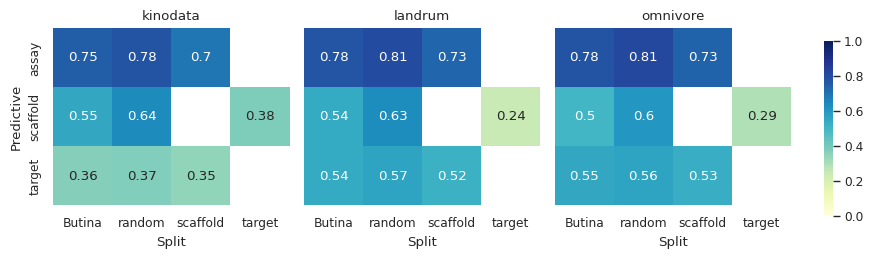

In [55]:
plot_heatmaps(df_results)
plt.savefig("mean_predictions_pearson.pdf")

/tmp/ipykernel_4965/2270807422.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar


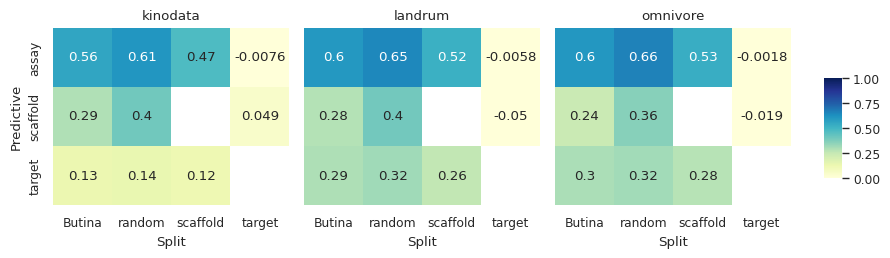

In [38]:
plot_heatmaps(df_results, metric="r2_mean")

/tmp/ipykernel_4965/2270807422.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar


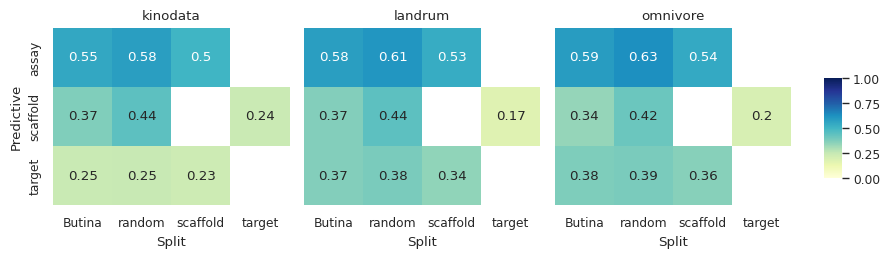

In [39]:
plot_heatmaps(df_results, metric="kendall_mean")

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_correlation_vs_overlap(df_results, corr_metric="pearson_mean"):
    """
    Plot correlation (Pearson or Kendall) vs. overlap for each dataset and predictive criterion.
    """
    sns.set(style="whitegrid", font_scale=1.1)

    plt.figure(figsize=(10, 6))
    ax = sns.scatterplot(
        data=df_results,
        x="overlap_mean",
        y=corr_metric,
        hue="dataset",
        style="predictive",
        s=100,
        alpha=0.8,
        edgecolor="black",
    )

    # Optional regression lines (one per dataset)
    sns.lmplot(
        data=df_results,
        x="overlap_mean",
        y=corr_metric,
        hue="dataset",
        scatter=False,
        aspect=1.5,
        height=6,
        truncate=True,
        line_kws={"linestyle": "--"},
    )

    ax.set_xlabel("Overlap [%]")
    ax.set_ylabel(f"{corr_metric.replace('_mean', '').capitalize()} Correlation")
    ax.set_title("Correlation vs. Overlap across Datasets and Predictive Criteria")
    plt.tight_layout()
    plt.show()

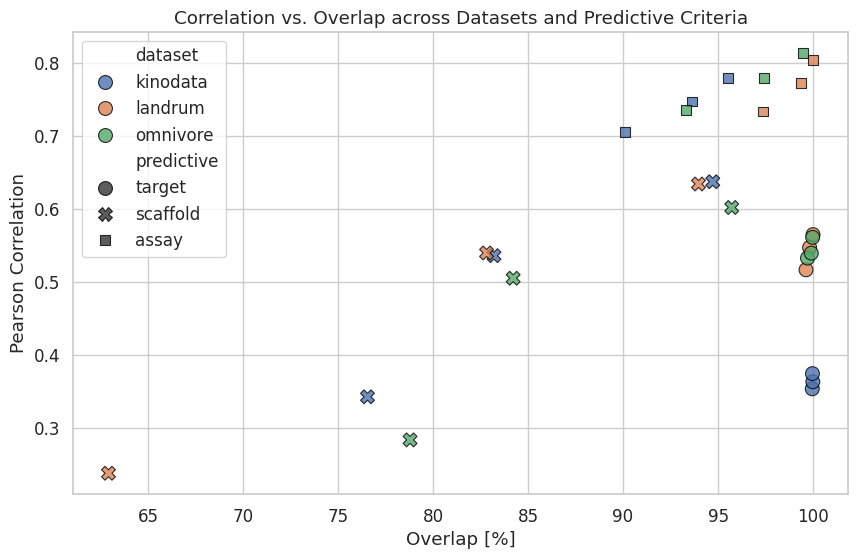

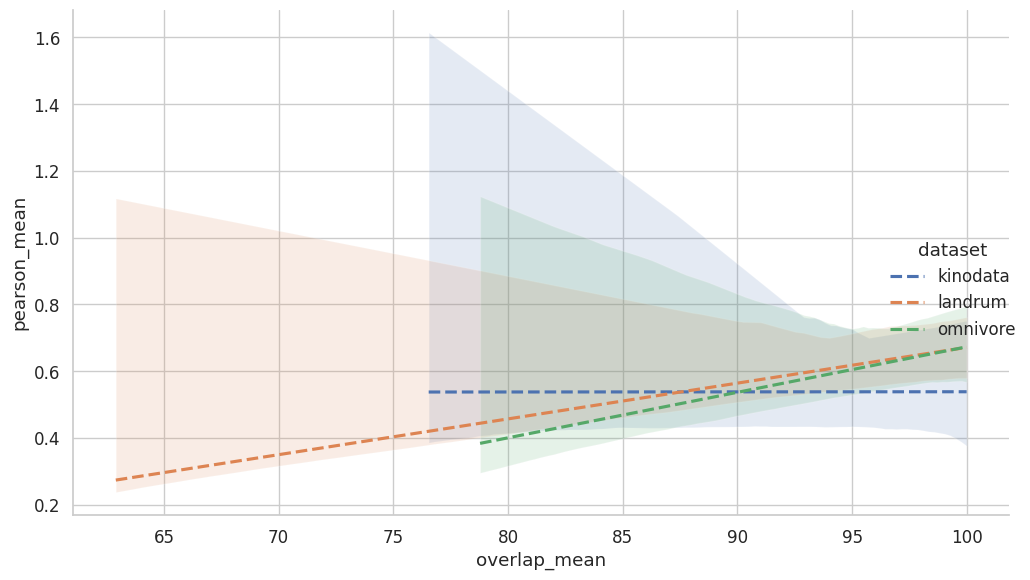

In [95]:
plot_correlation_vs_overlap(df_results)

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_grouped_bar_with_error(df_results, metric="pearson"):
    """
    Create grouped bar plots with error bars for a correlation metric (mean ± std),
    grouped by predictive × split and colored by dataset.

    Parameters:
    - df_results: DataFrame with columns like:
        ['predictive', 'split', 'dataset', 'pearson_mean', 'pearson_std']
    - metric: base name of the metric to plot ('pearson', 'kendall', etc.)
    """
    mean_col = f"{metric}_mean"
    std_col = f"{metric}_std"

    # Combine predictive + split for x-axis label
    df_plot = df_results.copy()
    df_plot["x_group"] = df_plot["predictive"] + " | " + df_plot["split"]

    # Set seaborn style
    sns.set(style="whitegrid", font_scale=1.2)
    plt.figure(figsize=(14, 6))

    # Barplot with error bars
    ax = sns.barplot(
        data=df_plot,
        x="x_group",
        y=mean_col,
        hue="dataset",
        palette="tab10",
        errorbar=None,  # We'll add custom error bars below
    )

    # Add error bars manually using std
    for (i, bar), (_, row) in zip(enumerate(ax.patches), df_plot.iterrows()):
        dataset_idx = i % len(df_plot["dataset"].unique())
        height = bar.get_height()
        std = row[std_col]
        ax.errorbar(
            x=bar.get_x() + bar.get_width() / 2,
            y=height,
            yerr=std,
            ecolor="black",
            capsize=5,
            fmt="none",
            lw=1,
            zorder=9,
        )

    # Formatting
    ax.set_title(f"{metric.capitalize()} Correlation (Mean ± Std)")
    ax.set_xlabel("Predictive | Split")
    ax.set_ylabel("Correlation")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Dataset")
    plt.tight_layout()
    plt.show()

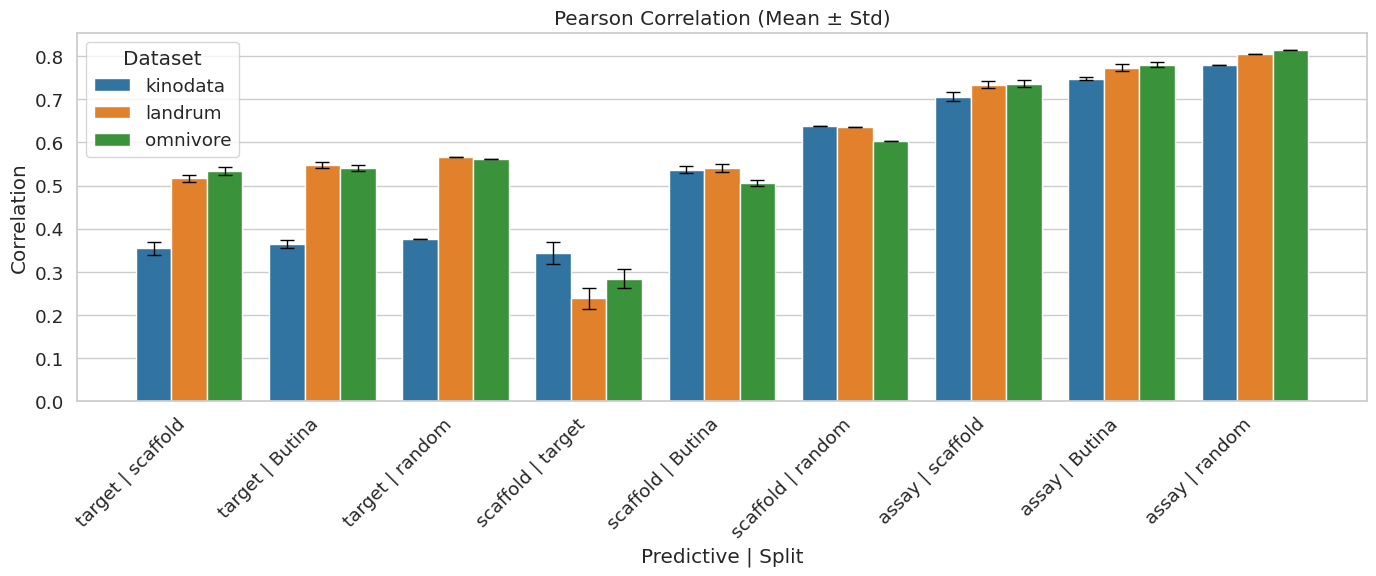

In [121]:
plot_grouped_bar_with_error(df_results)

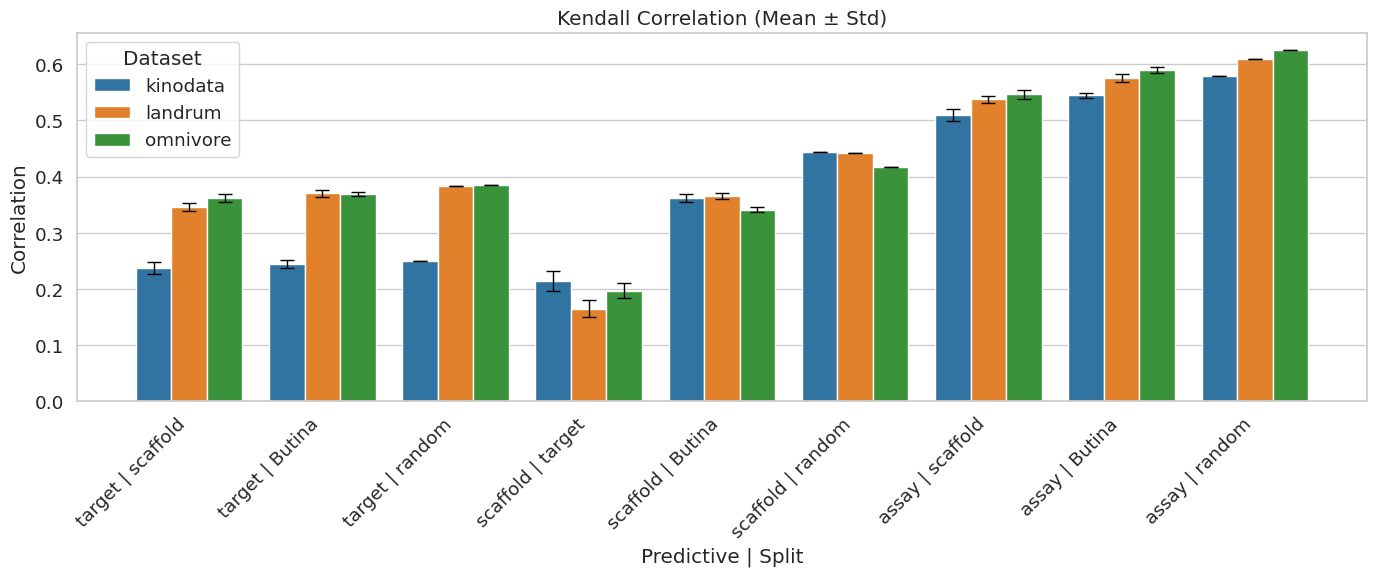

In [124]:
plot_grouped_bar_with_error(df_results, metric="kendall")

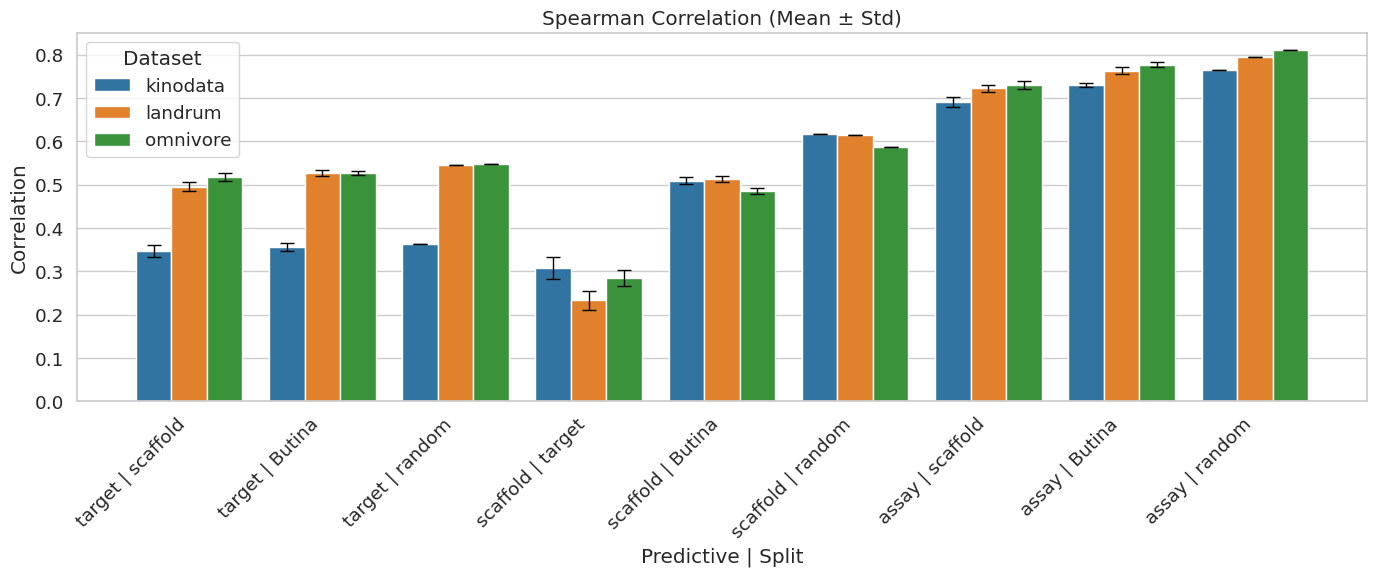

In [125]:
plot_grouped_bar_with_error(df_results, metric="spearman")